# Mix de generación y precio de la luz

**Objetivo:** ver de qué tecnologías viene la electricidad en España, cómo ha cambiado el mix y qué relación tiene cada tecnología con el precio del PVPC. Cada sección termina con lo que implica para el modelo.

**Datos:** generación diaria por tecnología del sistema eléctrico nacional (REE) y PVPC horario, desde junio de 2021. El peso de cada tecnología es el porcentaje que aporta a la generación total de ese día.

> Para reproducirlo: `make backfill` descarga los datos y después se ejecuta este notebook. Ver también `01_eda_precios.ipynb`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.ingestion.generation import RENEWABLE_TECHNOLOGIES, load_generation
from src.ingestion.prices import load_pvpc
from src.processing.clean import clean_prices

INK, BLUE, AMBER, GREY, GREEN = "#0E1726", "#1F4E9C", "#E99A1E", "#A9B4C2", "#2E7D5B"
GROUP_COLORS = {
    "Eólica": "#2E7D5B", "Solar": "#7CC4A0", "Hidráulica": "#4F82D6", "Otras renovables": "#A9C4EB",
    "Nuclear": "#4A5565", "Ciclo combinado": "#E99A1E", "Cogeneración y otras": "#C9D2DE",
}
GROUPS = {
    "Eólica": ["Eólica"], "Solar": ["Solar fotovoltaica", "Solar térmica"], "Hidráulica": ["Hidráulica", "Hidroeólica"],
    "Otras renovables": ["Otras renovables", "Residuos renovables"], "Nuclear": ["Nuclear"], "Ciclo combinado": ["Ciclo combinado"],
}
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.float_format", "{:.1f}".format)

# Generación: de formato largo a una columna por grupo de tecnologías
generation = load_generation()
wide = generation.pivot_table(index="date", columns="technology", values="mwh", aggfunc="sum").fillna(0)
wide.index = pd.to_datetime(wide.index)
groups = pd.DataFrame({name: wide[[t for t in techs if t in wide]].sum(axis=1) for name, techs in GROUPS.items()})
groups["Cogeneración y otras"] = wide.sum(axis=1) - groups.sum(axis=1)
share = groups.div(groups.sum(axis=1), axis=0) * 100
renewable = wide[[t for t in wide if t in RENEWABLE_TECHNOLOGIES]].sum(axis=1) / wide.sum(axis=1) * 100

# Precio: media del día y de dos franjas, en hora local
price = clean_prices(load_pvpc()).tz_convert("Europe/Madrid")["price"]
def daily_mean(series):
    out = series.resample("D").mean()
    out.index = out.index.tz_localize(None)
    return out
hour = price.index.hour
daily = pd.DataFrame({
    "price": daily_mean(price),
    "price_midday": daily_mean(price[(hour >= 12) & (hour < 16)]),
    "price_evening": daily_mean(price[(hour >= 19) & (hour < 22)]),
})

data = share.join(renewable.rename("renewable")).join(daily, how="inner")
recent = data[data.index.year >= 2023]
print(f"{len(data)} días con generación y precio, del {data.index.min():%d/%m/%Y} al {data.index.max():%d/%m/%Y}")

1952 días con generación y precio, del 01/06/2021 al 04/10/2026


## 1. Cómo ha cambiado el mix

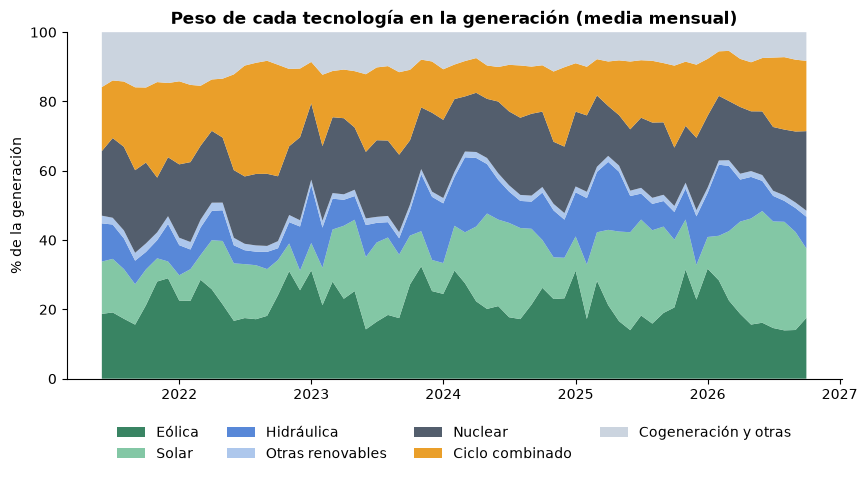

,Eólica,Solar,Hidráulica,Otras renovables,Nuclear,Ciclo combinado,Cogeneración y otras,Renovables
año,,,,,,,,
2021,21.3,11.2,8.3,2.2,20.8,21.2,15.0,43.0
2022,22.6,11.8,6.7,2.1,20.7,24.5,11.8,43.1
2023,23.4,16.1,9.8,1.7,20.8,17.8,10.4,51.0
2024,22.9,18.6,13.5,1.7,20.0,13.6,9.6,56.7
2025,21.4,19.9,12.5,1.7,19.0,16.8,8.7,55.5
2026,19.4,24.7,11.6,1.6,18.9,16.6,7.2,57.3


In [2]:
monthly_share = share.resample("MS").mean()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.stackplot(monthly_share.index, monthly_share.T, labels=monthly_share.columns,
             colors=[GROUP_COLORS[c] for c in monthly_share.columns], alpha=0.95)
ax.set(title="Peso de cada tecnología en la generación (media mensual)", ylabel="% de la generación", ylim=(0, 100))
ax.legend(frameon=False, ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.grid(False)
plt.show()

yearly = share.groupby(share.index.year).mean()
yearly["Renovables"] = renewable.groupby(renewable.index.year).mean()
yearly.rename_axis("año")

Las **renovables pasan del 43 % en 2021–2022 al 57 % en 2026.** El cambio más grande es la **solar, que se duplica** (del 11 % al 25 %). El **ciclo combinado (gas)** cae del 24,5 % en 2022 al 13,6 % en 2024 y se queda en torno al 17 %. La nuclear se mantiene estable, en torno al 19–21 %.

→ **Para el modelo:** el sistema eléctrico de 2026 no es el de 2021. Es coherente con lo visto en el notebook 01: mediodía cada vez más barato y más diferencia entre horas.

## 2. Renovables y precio

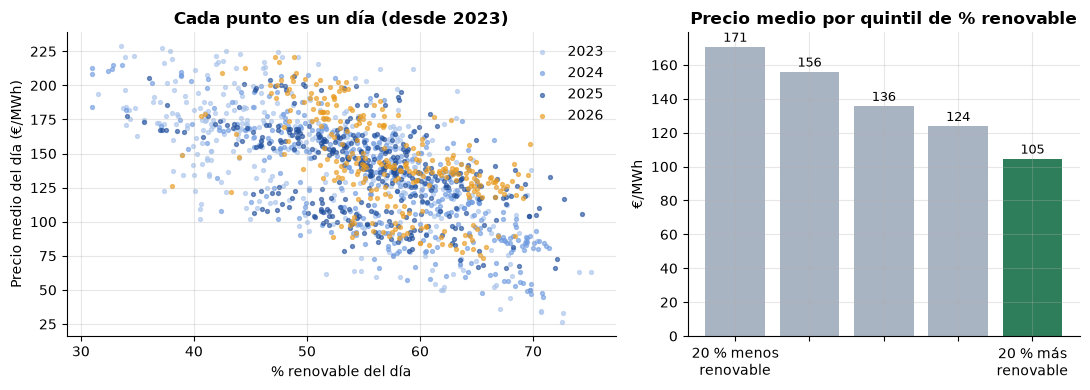

Correlación % renovable - precio: -0.67 en todo el histórico; por año:


date,2021,2022,2023,2024,2025,2026
correlación,-0.43,-0.52,-0.64,-0.75,-0.51,-0.58


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
for y, color in {2023: "#A9C4EB", 2024: "#6F9BE0", 2025: BLUE, 2026: AMBER}.items():
    sub = recent[recent.index.year == y]
    ax1.scatter(sub["renewable"], sub["price"], s=8, alpha=0.6, color=color, label=str(y))
ax1.set(title="Cada punto es un día (desde 2023)", xlabel="% renovable del día", ylabel="Precio medio del día (€/MWh)")
ax1.legend(frameon=False)

quintiles = recent.groupby(pd.qcut(recent["renewable"], 5, labels=False))["price"].mean()
ax2.bar(range(5), quintiles, color=[GREY, GREY, GREY, GREY, GREEN])
for i, v in enumerate(quintiles):
    ax2.text(i, v + 3, f"{v:.0f}", ha="center", fontsize=9)
ax2.set_xticks(range(5), ["20 % menos\nrenovable", "", "", "", "20 % más\nrenovable"])
ax2.set(title="Precio medio por quintil de % renovable", ylabel="€/MWh")
plt.tight_layout()
plt.show()

by_year = data.groupby(data.index.year).apply(lambda d: d["renewable"].corr(d["price"]), include_groups=False)
print(f"Correlación % renovable - precio: {data['renewable'].corr(data['price']):.2f} en todo el histórico; por año:")
by_year.map("{:.2f}".format).rename("correlación").to_frame().T

La relación es **clara y estable**: cuanto más renovable es el día, más barato. Desde 2023, el 20 % de días con menos renovables cuesta de media **171 €/MWh** y el 20 % con más, **105 €/MWh (−39 %)**. La correlación es de −0,67 en todo el histórico y está entre −0,43 y −0,75 cada año.

En el prototipo, con solo 30 días, salía −0,37: una ventana corta subestima la relación.

→ **Para el modelo:** el peso renovable es una de las mejores señales del precio de un día.

## 3. ¿Qué tecnología va con el precio?

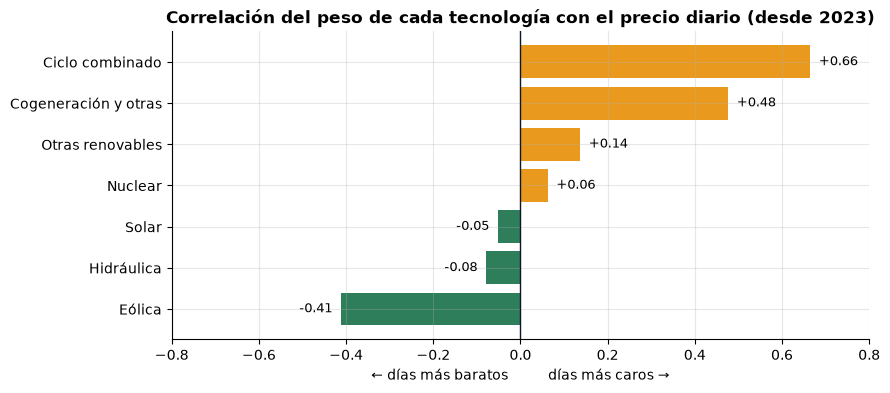

,todo el histórico,desde 2023
Eólica,-0.23,-0.41
Hidráulica,-0.34,-0.08
Solar,-0.34,-0.05
Nuclear,+0.05,+0.06
Otras renovables,+0.39,+0.14
Cogeneración y otras,+0.50,+0.48
Ciclo combinado,+0.65,+0.66


In [4]:
correlations = pd.DataFrame({
    "todo el histórico": data[share.columns].corrwith(data["price"]),
    "desde 2023": recent[share.columns].corrwith(recent["price"]),
}).sort_values("desde 2023")

fig, ax = plt.subplots(figsize=(9, 4))
values = correlations["desde 2023"]
ax.barh(values.index, values, color=[GREEN if v < 0 else AMBER for v in values])
for i, v in enumerate(values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color=INK, lw=1)
ax.set(title="Correlación del peso de cada tecnología con el precio diario (desde 2023)", xlim=(-0.8, 0.8))
ax.set_xlabel("← días más baratos          días más caros →")
plt.show()
correlations.map("{:+.2f}".format)

- **Ciclo combinado (gas): +0,66.** Es la tecnología que más se mueve con el precio. Cuando hace falta gas, la luz es cara, porque el gas suele marcar el precio en las horas en que entra.
- **Cogeneración y otras: +0,48.** También son en su mayoría térmicas de gas.
- **Eólica: −0,41.** Es la renovable que más abarata el día completo.
- **Solar e hidráulica:** casi nula sobre el precio medio del día desde 2023. La solar sí importa, pero dentro del día (sección 5).
- **Nuclear: ~0.** No se mueve con el precio porque produce casi lo mismo todos los días. En el prototipo salía −0,53 con 30 días: otra ventana corta que engañaba.

> Correlación no es causalidad: indica qué se mueve a la vez, no qué provoca qué.

## 4. El gas en detalle

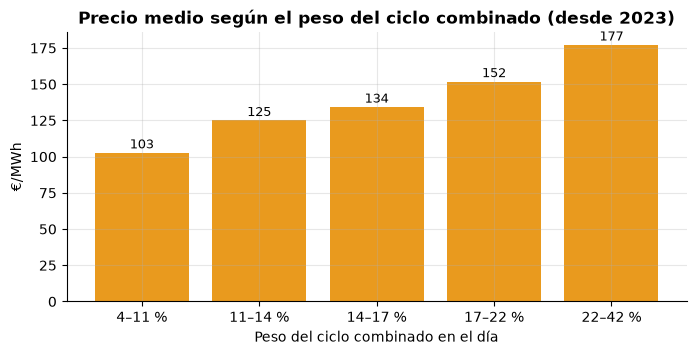

In [5]:
gas = recent.groupby(pd.qcut(recent["Ciclo combinado"], 5), observed=True)["price"].mean()
labels = [f"{iv.left:.0f}–{iv.right:.0f} %" for iv in gas.index]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(labels, gas, color=AMBER)
for i, v in enumerate(gas):
    ax.text(i, v + 3, f"{v:.0f}", ha="center", fontsize=9)
ax.set(title="Precio medio según el peso del ciclo combinado (desde 2023)", xlabel="Peso del ciclo combinado en el día", ylabel="€/MWh")
plt.show()

Los días con poco gas (menos del 11 % de la generación) cuestan de media **103 €/MWh**; los días con más del 22 %, **177 €/MWh (+72 %)**.

→ **Para el modelo:** cuánto gas va a hacer falta mañana es, en el fondo, lo que se quiere adivinar. Depende de cuánta renovable haya y de cuánta demanda.

## 5. Solar y eólica: a qué horas abaratan

In [6]:
intraday = pd.DataFrame({
    "precio de 12 a 16 h": recent[["Solar", "Eólica"]].corrwith(recent["price_midday"]),
    "precio de 19 a 22 h": recent[["Solar", "Eólica"]].corrwith(recent["price_evening"]),
    "precio medio del día": recent[["Solar", "Eólica"]].corrwith(recent["price"]),
})
intraday.map("{:+.2f}".format).rename_axis("correlación (desde 2023)")

,precio de 12 a 16 h,precio de 19 a 22 h,precio medio del día
correlación (desde 2023),,,
Solar,-0.38,+0.06,-0.05
Eólica,-0.11,-0.33,-0.41


- **La solar abarata el mediodía (−0,38) pero no la noche (+0,06).** Por eso apenas se nota en la media del día: explica el valle de las 14:00 que se veía en el notebook 01.
- **La eólica abarata sobre todo la noche (−0,33),** cuando no hay sol, y por eso influye más en la media del día.

→ **Para el modelo:** cada tecnología actúa a horas distintas. El modelo es horario, así que puede aprender esa interacción entre la hora y el mix.

## 6. ¿Se puede usar el mix para predecir?

In [7]:
lagged = recent.assign(renewable_prev_day=recent["renewable"].shift(1), gas_prev_day=recent["Ciclo combinado"].shift(1))
pd.DataFrame({
    "mismo día (D)": [lagged["renewable"].corr(lagged["price"]), lagged["Ciclo combinado"].corr(lagged["price"])],
    "día anterior (D-1)": [lagged["renewable_prev_day"].corr(lagged["price"]), lagged["gas_prev_day"].corr(lagged["price"])],
}, index=["% renovable", "% ciclo combinado"]).map("{:+.2f}".format).rename_axis("correlación con el precio de D")

,mismo día (D),día anterior (D-1)
correlación con el precio de D,,
% renovable,-0.64,-0.57
% ciclo combinado,+0.66,+0.55


Hay un problema importante: **al predecir el día D no se sabe cuánta renovable habrá en D.** La generación real se conoce cuando el día ya ha pasado.

- Usar la generación real de D sería una fuga de datos, como la que evitamos en las variables de precio.
- La del día anterior sí se conoce y conserva parte de la señal: −0,57 frente a −0,64 en renovables, y +0,55 frente a +0,66 en gas.

→ **Para el modelo:** la versión inicial puede añadir el mix del día anterior como variable. La mejora real llegará con las **previsiones** de demanda, eólica y solar que publica REE para el día siguiente (mejora 9.2 del plan).

## Conclusiones

| Hallazgo | Implicación para el modelo |
|---|---|
| Renovables del 43 % al 57 %; la solar se duplica y el gas baja | El sistema ha cambiado: dar más peso a los datos recientes |
| Días más renovables, más baratos (171 → 105 €/MWh entre quintiles) | El peso renovable es una de las mejores señales del precio |
| El gas es lo que más se mueve con el precio (+0,66) | En el fondo, se trata de adivinar cuánto gas hará falta |
| La solar abarata el mediodía y la eólica la noche | La interacción hora × mix la puede aprender un modelo horario |
| La generación de D no se conoce al predecir D | No usarla (sería una fuga); sí la de D-1 y, más adelante, las previsiones de REE |
| Con 30 días los resultados engañaban (nuclear −0,53, renovables −0,37) | Sacar conclusiones siempre con el histórico completo |